# 06 - Model Evaluation, Error Analysis & Visualization

Notebook này tập trung vào đánh giá chuyên sâu mô hình RL dựa trên các luật chơi mới:
- **Adjacency:** Sai lệch tối đa 1 lớp.
- **Binary Precision:** Phân tách tuyệt đối giữa Kẹt và Không kẹt.
- **Class Balance:** Đánh giá độ công bằng giữa 6 lớp.

In [7]:
import os
import sys
from pathlib import Path

# Add project root to sys.path
cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd] + list(cwd.parents) if (p / 'src').exists()), cwd)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from src.rl.artifacts import get_rl_evaluation_predictions_path
from src.rl.evaluation import compute_ops_metrics

In [8]:
# ==== Input config ====
RUN_ID = os.getenv('RL_RUN_ID', 'notebook_warmstart_h15')
MODE = os.getenv('RL_MODE', 'warmstart')

PREDICTIONS_PATH = get_rl_evaluation_predictions_path(mode=MODE, run_id=RUN_ID)

assert PREDICTIONS_PATH.exists(), f'Không tìm thấy file kết quả: {PREDICTIONS_PATH}'

eval_df = pd.read_parquet(PREDICTIONS_PATH)
y_true = eval_df['y_true'].to_numpy()
y_pred = eval_df['y_pred'].to_numpy()

print(f"Nạp dữ liệu thành công từ: {PREDICTIONS_PATH}")
print(f"Tổng số mẫu đánh giá: {len(eval_df)}")

Nạp dữ liệu thành công từ: /app/artifacts/rl/evaluation/predictions_warmstart_notebook_warmstart_h15.parquet
Tổng số mẫu đánh giá: 152859


## 0. Model Comparison: RL vs SL (LSTM)

So sánh trực tiếp giữa mô hình Học tăng cường (RL) và mô hình Học giám sát (LSTM cổ điển) dựa trên các tiêu chí vận hành thực tế.

In [ ]:
# ==== SL & Vanilla Prediction Config ====
SL_PREDICTIONS_PATH = PROJECT_ROOT / "artifacts" / "ml" / "evaluation" / f"predictions_sl_manual_h15.parquet"
VANILLA_PREDICTIONS_PATH = PROJECT_ROOT / "artifacts" / "ml" / "evaluation" / "predictions_vanilla.parquet"

sl_eval_df = None
if SL_PREDICTIONS_PATH.exists():
    sl_eval_df = pd.read_parquet(SL_PREDICTIONS_PATH)
    y_true_sl = sl_eval_df['y_true'].to_numpy()
    y_pred_sl = sl_eval_df['y_pred'].to_numpy()
    print(f"✅ Nạp dữ liệu SL thành công từ: {SL_PREDICTIONS_PATH}")

vanilla_eval_df = None
if VANILLA_PREDICTIONS_PATH.exists():
    vanilla_eval_df = pd.read_parquet(VANILLA_PREDICTIONS_PATH)
    y_true_vanilla = vanilla_eval_df['y_true'].to_numpy()
    y_pred_vanilla = vanilla_eval_df['y_pred'].to_numpy()
    print(f"✅ Nạp dữ liệu Vanilla thành công từ: {VANILLA_PREDICTIONS_PATH}")

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_detailed_comparison(y_true, y_pred, name="Model"):
    # 1. Adjacency Accuracy (error <= 1 class)
    diff = np.abs(y_true - y_pred)
    adj_acc = np.mean(diff <= 1)
    
    # 2. Binary State Analysis (Congested vs Free-flow)
    y_true_bin = (y_true >= 3).astype(int)
    y_pred_bin = (y_pred >= 3).astype(int)
    
    # False Alarm: Thực tế Thoáng -> Dự báo Kẹt
    false_alarms = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    fa_rate = false_alarms / np.sum(y_true_bin == 0) if np.sum(y_true_bin == 0) > 0 else 0
    
    # Missed Detection: Thực tế Kẹt -> Dự báo Thoáng
    misses = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    miss_rate = misses / np.sum(y_true_bin == 1) if np.sum(y_true_bin == 1) > 0 else 0
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    return {
        "Model Name": name,
        "Accuracy": acc,
        "Macro F1": f1,
        "Adj. Acc (±1 class)": adj_acc,
        "Thoáng -> Kẹt (False Alarm)": fa_rate,
        "Kẹt -> Thoáng (Miss)": miss_rate
    }

results = []
results.append(compute_detailed_comparison(y_true, y_pred, name="RL Model (DQN)"))

if sl_eval_df is not None:
    results.append(compute_detailed_comparison(y_true_sl, y_pred_sl, name="SL Model (Hybrid)"))

if vanilla_eval_df is not None:
    results.append(compute_detailed_comparison(y_true_vanilla, y_pred_vanilla, name="Vanilla LSTM (Pure Dynamic)"))

comparison_summary = pd.DataFrame(results)
display(comparison_summary.style.highlight_max(subset=["Accuracy", "Macro F1", "Adj. Acc (±1 class)"], color='lightgreen')\
                          .highlight_min(subset=["Thoáng -> Kẹt (False Alarm)", "Kẹt -> Thoáng (Miss)"], color='lightgreen'))

## 0. Model Comparison: RL vs SL (LSTM)

So sánh trực tiếp giữa mô hình Học tăng cường (RL) và mô hình Học giám sát (LSTM cổ điển) dựa trên các tiêu chí vận hành thực tế.

In [ ]:
# ==== SL Prediction Config ====
SL_PREDICTIONS_PATH = PROJECT_ROOT / "artifacts" / "ml" / "evaluation" / f"predictions_sl_manual_h15.parquet"

if SL_PREDICTIONS_PATH.exists():
    sl_eval_df = pd.read_parquet(SL_PREDICTIONS_PATH)
    y_true_sl = sl_eval_df['y_true'].to_numpy()
    y_pred_sl = sl_eval_df['y_pred'].to_numpy()
    print(f"✅ Nạp dữ liệu SL thành công từ: {SL_PREDICTIONS_PATH}")
    print(f"Tổng số mẫu SL: {len(sl_eval_df)}")
else:
    print(f"⚠️ Không tìm thấy file kết quả SL: {SL_PREDICTIONS_PATH}")
    sl_eval_df = None

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_detailed_comparison(y_true, y_pred, name="Model"):
    # 1. Adjacency Accuracy (error <= 1 class)
    diff = np.abs(y_true - y_pred)
    adj_acc = np.mean(diff <= 1)
    
    # 2. Binary State Analysis (Congested vs Free-flow)
    # Mapping: {0,1,2} -> 0 (Free), {3,4,5} -> 1 (Congested)
    y_true_bin = (y_true >= 3).astype(int)
    y_pred_bin = (y_pred >= 3).astype(int)
    
    # False Alarm: Thực tế Thoáng (0,1,2) -> Dự báo Kẹt (3,4,5)
    false_alarms = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    fa_rate = false_alarms / np.sum(y_true_bin == 0) if np.sum(y_true_bin == 0) > 0 else 0
    
    # Missed Detection: Thực tế Kẹt (3,4,5) -> Dự báo Thoáng (0,1,2)
    misses = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    miss_rate = misses / np.sum(y_true_bin == 1) if np.sum(y_true_bin == 1) > 0 else 0
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    return {
        "Model Name": name,
        "Accuracy": acc,
        "Macro F1": f1,
        "Adj. Acc (±1 class)": adj_acc,
        "Thoáng -> Kẹt (False Alarm)": fa_rate,
        "Kẹt -> Thoáng (Miss)": miss_rate
    }

results = []
results.append(compute_detailed_comparison(y_true, y_pred, name="RL Model (DQN)"))

if sl_eval_df is not None:
    results.append(compute_detailed_comparison(y_true_sl, y_pred_sl, name="LSTM Model (SL)"))

comparison_summary = pd.DataFrame(results)
display(comparison_summary.style.highlight_max(subset=["Accuracy", "Macro F1", "Adj. Acc (±1 class)"], color='lightgreen')\
                          .highlight_min(subset=["Thoáng -> Kẹt (False Alarm)", "Kẹt -> Thoáng (Miss)"], color='lightgreen'))

## 1. Visualization: Confusion Matrix & Adjacency Analysis

Mục tiêu: Các điểm sáng tập trung tại đường chéo và các ô lân cận (Adjacency).

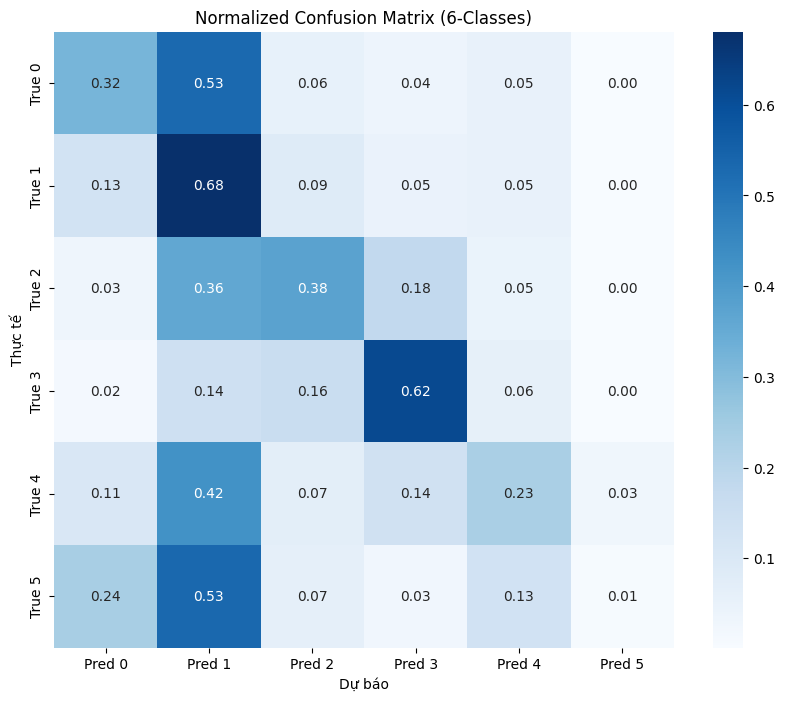

In [9]:
cm = confusion_matrix(y_true, y_pred, labels=range(6), normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=[f'Pred {i}' for i in range(6)], 
            yticklabels=[f'True {i}' for i in range(6)])
plt.title('Normalized Confusion Matrix (6-Classes)')
plt.xlabel('Dự báo')
plt.ylabel('Thực tế')
plt.show()

/tmp/ipykernel_915/2274807548.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_pct.index, y=error_pct.values, palette='viridis')


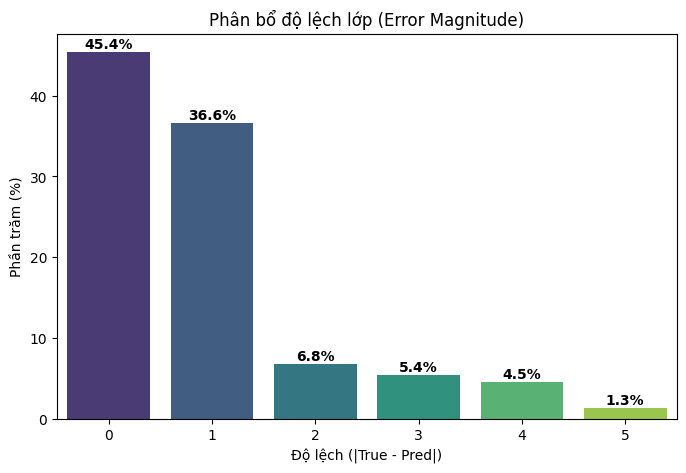

Tỉ lệ tuân thủ luật Adjacency (Lệch <= 1 lớp): 81.97%


In [10]:
diffs = np.abs(y_true - y_pred)
error_counts = pd.Series(diffs).value_counts().sort_index()
error_pct = error_counts / len(diffs) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=error_pct.index, y=error_pct.values, palette='viridis')
plt.title('Phân bổ độ lệch lớp (Error Magnitude)')
plt.xlabel('Độ lệch (|True - Pred|)')
plt.ylabel('Phần trăm (%)')
for i, val in enumerate(error_pct.values):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
plt.show()

print(f"Tỉ lệ tuân thủ luật Adjacency (Lệch <= 1 lớp): {error_pct.get(0, 0) + error_pct.get(1, 0):.2f}%")

## 2. Binary Analysis: Congested vs Non-Congested

Nhóm: {0,1,2} -> 0 (Thông thoáng), {3,4,5} -> 1 (Kẹt xe).

Binary Classification Report ({0,1,2} vs {3,4,5}):
              precision    recall  f1-score   support

 Thanh thoát       0.86      0.85      0.86    122049
      Kẹt xe       0.44      0.46      0.45     30810

    accuracy                           0.77    152859
   macro avg       0.65      0.66      0.65    152859
weighted avg       0.78      0.77      0.78    152859



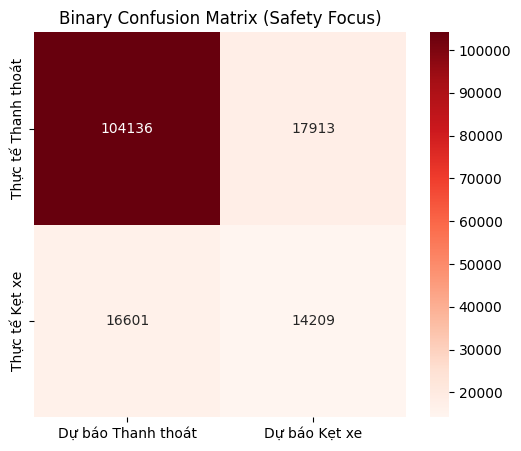

🚩 Miss Rate (Bỏ lỡ kẹt xe - CẦN GIẢM): 53.88%
⚠️ False Alarm Rate (Báo nhầm - CHẤP NHẬN ĐƯỢC): 14.68%


In [11]:
y_true_bin = (y_true >= 3).astype(int)
y_pred_bin = (y_pred >= 3).astype(int)

print('Binary Classification Report ({0,1,2} vs {3,4,5}):')
print(classification_report(y_true_bin, y_pred_bin, target_names=['Thanh thoát', 'Kẹt xe']))

cm_bin = confusion_matrix(y_true_bin, y_pred_bin)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Dự báo Thanh thoát', 'Dự báo Kẹt xe'], 
            yticklabels=['Thực tế Thanh thoát', 'Thực tế Kẹt xe'])
plt.title('Binary Confusion Matrix (Safety Focus)')
plt.show()

tn, fp, fn, tp = cm_bin.ravel()
miss_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
false_alarm = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"🚩 Miss Rate (Bỏ lỡ kẹt xe - CẦN GIẢM): {miss_rate:.2%}")
print(f"⚠️ False Alarm Rate (Báo nhầm - CHẤP NHẬN ĐƯỢC): {false_alarm:.2%}")

## 3. Class Balance: 6-Class Recognition Equality

Đánh giá xem 6 lớp có được nhận diện đồng đều không (Macro F1).

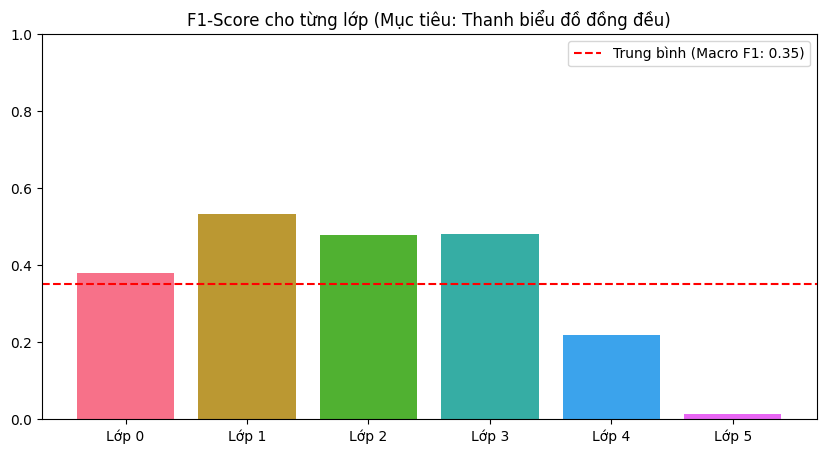

In [12]:
report = classification_report(y_true, y_pred, output_dict=True, labels=range(6), zero_division=0)
f1_scores = [report[str(i)]['f1-score'] for i in range(6)]

plt.figure(figsize=(10, 5))
plt.bar([f'Lớp {i}' for i in range(6)], f1_scores, color=sns.color_palette('husl', 6))
plt.axhline(np.mean(f1_scores), color='red', linestyle='--', label=f'Trung bình (Macro F1: {np.mean(f1_scores):.2f})')
plt.title('F1-Score cho từng lớp (Mục tiêu: Thanh biểu đồ đồng đều)')
plt.ylim(0, 1.0)
plt.legend()
plt.show()